# SASRec → target-conditioned QFormer → LLM recommender

Binary click/rating prediction ("Yes"/"No") on CoLLM's MovieLens-1M benchmark.
**Primary metric: UAUC** (per-user AUC averaged over users); secondary: global AUC, NDCG@k.

## Architecture

```
history ids ──> SASRec (frozen after Phase 0) ──> H ∈ [B, L, d]   (ALL positions)
                                                    │ keys/values
target id ──> e_i ──> FiLM ──> Q' = γ(e_i)·Q + β(e_i)
                                                    │ queries
                                     QFormer (self-attn + cross-attn)
                                                    │
                          N ×〈UserID〉tokens + 1 ×〈TargetItemID〉token
                                                    │  spliced into inputs_embeds
                        frozen LLM + LoRA ──> P("Yes") at the answer position
```

**Why a QFormer instead of CoLLM's MLP?** CoLLM compresses the entire history into one
pooled SASRec vector and MLP-maps it to a single soft token — an information bottleneck.
The QFormer's N learnable queries cross-attend over *every* history position, so different
queries can specialize (genre affinity, recency, niche taste) and the LLM receives N tokens
of user representation.

**Two-level target injection (by design).** The target item enters the model twice:
1. **Early** — its SASRec embedding FiLM-modulates the QFormer queries *before*
   cross-attention (`Q' = γ(e_i)·Q + β(e_i)`), so the bridge reads out *"how does this
   history relate to items like this candidate"* rather than a generic profile. γ is
   parameterized as `1 + Δγ` with `Δγ` initialized to zero, so training starts at the
   target-agnostic model and learns how much conditioning helps (`target_aware=False`
   gives the agnostic control).
2. **Late** — its title and one projected item soft token appear in the prompt, letting
   the LLM do the final semantic matching.

**Training** is phase-driven (SASRec CTR pre-training → LoRA warm-up on text-only prompts
→ QFormer-only training on the hybrid prompt), the loss adds a **within-user pairwise
(BPR) term** that directly targets UAUC, and the final model is a **weight-averaged soup**
of the top-k checkpoints selected by *smoothed* validation UAUC with a bootstrap noise band.


## ⬇ Google Colab setup (skip if running locally)

Open this notebook straight from GitHub (`File → Open notebook → GitHub`) and run the
cell below: it clones the repo, installs the two packages Colab lacks, and unpacks the
CoLLM ML-1M data. On a **T4 (16 GB)** use `cfg.load_4bit = True` for the full Vicuna-7B
run; an A100 runs it in bf16 without quantization.

In [1]:
import sys, os
if "google.colab" in sys.modules and not os.path.exists("config.py"):
    # MUST be set before huggingface_hub is ever imported (it reads these into
    # module constants at import time). Xet is disabled outright: its CAS
    # servers 401 on fine-grained tokens even when whoami() passes, and the
    # classic HTTP path is equally fast here with hf_transfer.
    os.environ["HF_HUB_DISABLE_XET"] = "1"
    os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
    # HF auth: unauthenticated requests are rate-limited, which matters for the
    # ~15GB backbone pulls. Add a (free, CLASSIC 'Read') token under Colab's
    # key icon (Secrets) as HF_TOKEN.
    try:
        from google.colab import userdata
        os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN").strip()
        from huggingface_hub import whoami
        print("HF token OK:", whoami()["name"])
    except Exception as e:
        # an INVALID token is worse than none: HF's Xet storage returns
        # 401 on bad credentials where anonymous requests would succeed
        os.environ.pop("HF_TOKEN", None)
        print(f"HF_TOKEN missing/invalid ({type(e).__name__}) -> anonymous downloads")
    %pip -q install hf_transfer
    !git clone https://github.com/htainvn/qformer-rec.git repo_src
    %cd repo_src
    %pip -q install peft accelerate bitsandbytes
    # Colab ships torchao 0.10, which recent peft rejects (needs >=0.16); we
    # don't use torchao, so remove it rather than upgrade it
    %pip -q uninstall -y torchao
    !unzip -o -q ml-1m.zip
    print("Colab setup done:", os.getcwd())

## 0 · Configuration

`smoke_test=True` (default) runs the whole pipeline on tiny synthetic data with a tiny
random GPT-2 backbone — CPU-only, a few minutes end-to-end. The clearly marked cell below
switches to the full Vicuna-7B multi-seed run on the real ML-1M pickles (needs a GPU).

In [2]:
try:                      # local-dev convenience; the autoreload extension is
    %load_ext autoreload  # broken on Colab's Python 3.12 image ('imp' removed)
    %autoreload 2
except Exception:
    pass

import numpy as np, torch, matplotlib.pyplot as plt, json, warnings
warnings.filterwarnings("ignore")
from torch.utils.data import DataLoader

from config import Config
from data import load_data, collate
from models import SASRec
from models.llm_rec import fill_titles
from train import (seed_everything, train_phase0, train_phase1, train_phase2,
                   build_models, load_tracked_state, eval_sasrec, run_all_phases)
from evaluate import (score_dataset, full_report, paired_user_test, qualifying_users,
                      comparison_table, ndcg_at_k, stratified_uauc, support_weighted_uauc,
                      BASELINES, TARGETS, auc as auc_fn, uauc as uauc_fn)

cfg = Config.smoke()          # <- default: runs out of the box on CPU
SEEDS = list(range(cfg.seed, cfg.seed + cfg.n_seeds))
print(f"backbone={cfg.backbone}  smoke_test={cfg.smoke_test}  seeds={SEEDS}")

backbone=hf-internal-testing/tiny-random-gpt2  smoke_test=True  seeds=[42, 43]


### ⚠️ FULL RUN — uncomment to train Vicuna-7B on the real ML-1M (GPU required)
This is the configuration used for the reported numbers: `lmsys/vicuna-7b-v1.5` frozen +
LoRA(r=8, α=16 on q_proj/v_proj), 3 seeds, model soup of top-3 checkpoints. Expect several
hours per seed on a single A100 (use `load_4bit=True` to fit smaller GPUs).

In [3]:
# cfg = Config()                       # full ML-1M; defaults: Vicuna-7B, LoRA r16/a32
#                                        # on 7 targets, 20 prompt titles, lambda_pair 0.8
# cfg.phase3_joint_finetune = True       # reader co-adaptation (recommended)
# cfg.n_seeds = 3                        # 3-5 seeds for the reported mean ± std
#
# # --- backbone tracks ---
# # Vicuna (default): direct comparison against published CoLLM/BinLLM numbers
# # cfg.backbone = "Qwen/Qwen2.5-7B"     # modern-reader track (tokenizer verified);
# #                                      # NOT comparable to published Vicuna baselines
#
# # --- other switches ---
# # cfg.val_subsample_users = 0          # selection on full val (default: 300 users)
# # cfg.load_4bit = True                 # QLoRA-quantize the frozen backbone if VRAM-bound
# # cfg.unfreeze_sasrec = True           # Phase 2b variant
# # cfg.design2 = True                   # DIN-fused values (measured no-go on ML-1M)
# SEEDS = list(range(cfg.seed, cfg.seed + cfg.n_seeds))
# print(f"backbone={cfg.backbone}  seeds={SEEDS}")

### Pre-download the backbone
Runs the (possibly long) weight download as its own step with visible progress,
so the training cells start instantly afterward.

In [4]:
# Pre-download the backbone weights BEFORE training (one-time per VM, cached).
# Pulls whichever weight format the repo actually hosts: Qwen ships safetensors;
# Vicuna ships ONLY .bin (the model loader is configured to use those directly
# instead of fetching the Hub's auto-converted safetensors duplicate).
if not cfg.smoke_test:
    from huggingface_hub import list_repo_files, snapshot_download
    files = list_repo_files(cfg.backbone)
    has_st = any(f.endswith(".safetensors") for f in files)
    weights = (["*.safetensors", "*.safetensors.index.json"] if has_st
               else ["*.bin", "*.bin.index.json"])
    patterns = weights + ["config.json", "generation_config.json", "tokenizer*",
                          "*.model", "vocab*", "merges*", "special_tokens*"]
    try:
        path = snapshot_download(cfg.backbone, allow_patterns=patterns)
    except RuntimeError as e:   # Xet/CAS backend failure -> classic HTTP path.
        # NB: the env var is read at import time; patch the live constant too.
        from huggingface_hub import constants
        constants.HF_HUB_DISABLE_XET = True
        print(f"xet download failed ({e}); retrying via classic HTTP")
        path = snapshot_download(cfg.backbone, allow_patterns=patterns)
    print(f"backbone cached at: {path}  (format: {'safetensors' if has_st else 'bin'})")
else:
    print("smoke mode - tiny backbone downloads in seconds, no pre-fetch needed")

smoke mode - tiny backbone downloads in seconds, no pre-fetch needed


## 1 · Data

CoLLM's preprocessed ML-1M (timestamp-split, label = rating > 3): 839 users, 3,256 items,
33,891 / 10,401 / 7,331 train/val/test. Ids are 1-based with 0 as the padding/no-history
placeholder; histories are capped to the 10 most recent liked items and left-padded.
In smoke mode a latent-factor synthetic dataset with the same schema is generated instead.

In [5]:
seed_everything(cfg.seed)
DEVICE = cfg.resolve_device()
train_ds, val_ds, test_ds, n_users, n_items, id2title = load_data(cfg)

print(f"device={DEVICE}")
print(f"train/val/test = {len(train_ds)} / {len(val_ds)} / {len(test_ds)}")
print(f"n_users={n_users}  n_items={n_items}  titles={len(id2title)}")
labels = train_ds.label
print(f"train positive rate: {labels.mean():.3f}")
his_lens = [int(m) for m in (np.array([sum(1 for i in h if i != 0) for h in train_ds.his]))]
print(f"history length (post-cap): mean {np.mean(his_lens):.1f}, max {max(his_lens)}")

device=mps
train/val/test = 1500 / 400 / 400
n_users=60  n_items=120  titles=120
train positive rate: 0.500
history length (post-cap): mean 6.5, max 10


In [6]:
# A sample prompt, exactly as the LLM sees it (soft-token slots marked):
s = train_ds[min(500, len(train_ds) - 1)]
seg_a, seg_b, seg_c = fill_titles(s["his_titles"], s["target_title"], hybrid=True)
print(seg_a + f"[{cfg.n_queries} × <UserID soft tokens>]" + seg_b
      + "[1 × <TargetItemID soft token>]" + seg_c)
print("\nlabel:", s["label"])

#Question: A user has given high ratings to the following movies: "Synthetic Movie #75 (1995)", "Synthetic Movie #58 (1978)", "Synthetic Movie #48 (2018)", "Synthetic Movie #49 (2019)", "Synthetic Movie #32 (2002)", "Synthetic Movie #105 (1975)", "Synthetic Movie #86 (2006)", "Synthetic Movie #30 (2000)". Additionally, we have information about the user's preferences encoded in the feature [2 × <UserID soft tokens>]. Using all available information, make a prediction about whether the user would enjoy the movie titled "Synthetic Movie #69 (1989)" with the feature [1 × <TargetItemID soft token>]? Answer with "Yes" or "No". 
#Answer:

label: 0.0


## 2 · Phase 0 — SASRec pre-training (sequential CTR, BCE)

SASRec trains standalone: dot(last hidden state, target item embedding) → BCE. The best
epoch by val AUC is saved to `checkpoints/sasrec.pt` and frozen for Phases 1–2 (unless
`unfreeze_sasrec` re-opens it in Phase 2b).

[phase0] epoch 1/3 loss 0.6944 val AUC 0.5639 val UAUC 0.5737


[phase0] epoch 2/3 loss 0.6883 val AUC 0.5794 val UAUC 0.5487


[phase0] epoch 3/3 loss 0.6850 val AUC 0.5759 val UAUC 0.5498
[phase0] saved best (val UAUC 0.5737) -> checkpoints/sasrec.pt


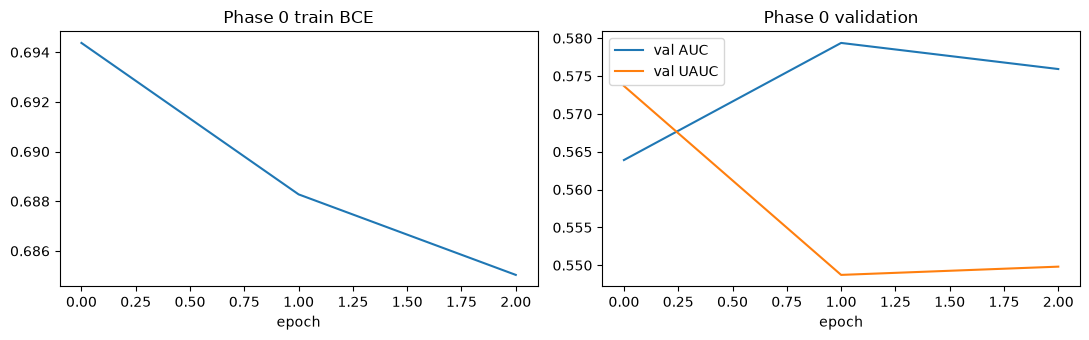

In [7]:
sasrec, hist0 = train_phase0(cfg, train_ds, val_ds, n_items, DEVICE)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist0["loss"]); ax[0].set_title("Phase 0 train BCE"); ax[0].set_xlabel("epoch")
ax[1].plot(hist0["val_auc"], label="val AUC"); ax[1].plot(hist0["val_uauc"], label="val UAUC")
ax[1].set_title("Phase 0 validation"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 3 · Phase 1 — LoRA warm-up on the text-only prompt

The LLM (backbone frozen; only LoRA trains) first learns the *task format* — answer
"Yes"/"No" about a movie given history titles — with **no** collaborative tokens. This way
Phase 2's gradients reflect collaborative signal rather than prompt-format learning.
The loss is already BCE + λ·within-user BPR (the pairwise term needs the user-grouped
batch sampler, which guarantees same-user positive/negative pairs inside a batch).

Loading weights:   0%|          | 0/64 [00:00<?, ?it/s]

[phase1] 5,120 trainable params, 58 qualifying val users for selection, backbone torch.float32, grad scaler off


[phase1] epoch 1 step 10/375 loss 0.7455 (bce 0.7157 pair 0.0596) 7.65 step/s


[phase1] epoch 1 step 20/375 loss 0.6882 (bce 0.6882 pair 0.0000) 9.66 step/s


[select] step 20: val UAUC 0.4700 val AUC 0.5194 (smoothed auc 0.5194)


...

[select] step 200: val UAUC 0.4682 val AUC 0.5200 (smoothed auc 0.5199)


[phase1] epoch 1 step 210/375 loss 0.6882 (bce 0.6882 pair 0.0000) 8.92 step/s


[phase1] epoch 1 step 220/375 loss 0.7020 (bce 0.7020 pair 0.0000) 15.31 step/s


[select] step 220: val UAUC 0.4680 val AUC 0.5196 (smoothed auc 0.5198)
[phase1] early stop at step 220 (patience)
[phase1] epoch 1/1 mean loss 0.7082
[select] noise band ±0.0595 on auc: 11 checkpoint(s) tied at top; ties broken by uauc
[phase1] saved LoRA -> checkpoints/lora_phase1.pt


[headroom] held-out half (29 users):
[headroom]   text-only LLM : AUC 0.5226 UAUC 0.4674
[headroom]   SASRec alone  : AUC 0.5738 UAUC 0.5426
[headroom]   optimal blend : AUC 0.5678 UAUC 0.5536
[headroom]   Phase-2 ceiling (blend - text): dAUC +0.0451 dUAUC +0.0863  <- if ~0, a flat Phase 2 is EXPECTED


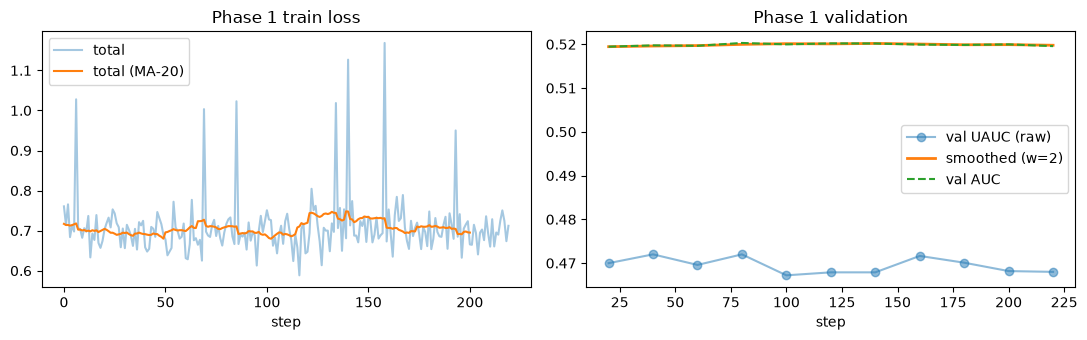

In [8]:
llm, _, qformer = build_models(cfg, n_items, DEVICE)
sasrec = sasrec.to(DEVICE)

sel1, hist1 = train_phase1(cfg, llm, sasrec, qformer, train_ds, val_ds, DEVICE)

steps1, raw1, smooth1, auc1 = sel1.curves()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist1["loss"], alpha=.4, label="total")
ax[0].plot(np.convolve(hist1["loss"], np.ones(20)/20, mode="valid"), label="total (MA-20)")
ax[0].set_title("Phase 1 train loss"); ax[0].set_xlabel("step"); ax[0].legend()
ax[1].plot(steps1, raw1, "o-", alpha=.5, label="val UAUC (raw)")
ax[1].plot(steps1, smooth1, "-", lw=2, label=f"smoothed (w={cfg.sel_window})")
ax[1].plot(steps1, auc1, "--", label="val AUC")
ax[1].set_title("Phase 1 validation"); ax[1].set_xlabel("step"); ax[1].legend()
plt.tight_layout(); plt.show()

## 4 · Phase 2 — train the QFormer bridge on the full hybrid prompt

LLM **and** LoRA are now frozen (Phase-1 weights loaded); only the QFormer + projection
heads receive gradients — which flow through `inputs_embeds` at the soft-token positions.
SASRec stays frozen (Phase 2b flips `cfg.unfreeze_sasrec`). We deliberately do **not**
train LoRA and the QFormer jointly in one step: per CoLLM's ablations the LoRA gradient
dominates early and the mapping module never learns to carry collaborative information
(worst on cold users).

Checkpoint selection here is the robust machinery from `selection.py`: smoothed val UAUC
+ bootstrap noise band (AUC breaks ties only inside the band) + patience early stopping;
the final model is the **weight-averaged soup** of the top-k checkpoints.

[phase2] 55,520 trainable params, 58 qualifying val users for selection, backbone torch.float32, grad scaler off


[phase2] epoch 1 step 10/750 loss 0.7296 (bce 0.6958 pair 0.0677) 8.91 step/s


[phase2] epoch 1 step 20/750 loss 0.6911 (bce 0.6911 pair 0.0000) 11.92 step/s


[phase2] epoch 1 step 30/750 loss 0.6953 (bce 0.6953 pair 0.0000) 9.10 step/s


[phase2] epoch 1 step 40/750 loss 0.7116 (bce 0.7116 pair 0.0000) 10.20 step/s


...

[soup] + step 50: auc 0.5045 uauc 0.4905 (rejected)


[soup] + step 100: auc 0.5042 uauc 0.4891 (rejected)


[soup] + step 200: auc 0.5044 uauc 0.4905 (rejected)


[soup] learned soup auc 0.5046 guard 0.4891 vs floor 0.5035/0.4850 -> keeping bridge
[phase2] saved souped QFormer -> checkpoints/qformer.pt


[ablation] soft tokens learned: val AUC 0.5046 UAUC 0.4891
[ablation] soft tokens zeroed : val AUC 0.5035 UAUC 0.4850
[ablation] token contribution : dAUC +0.0010 dUAUC +0.0040


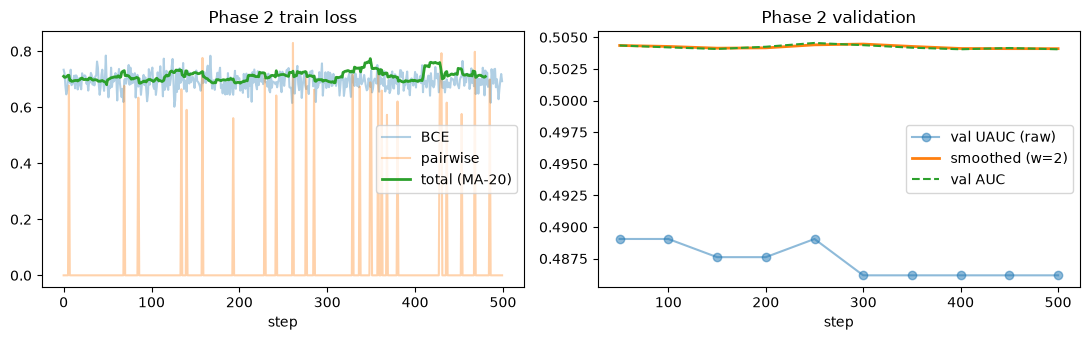

In [9]:
if cfg.qformer_align_pretrain:
    from train import align_pretrain_qformer
    align_pretrain_qformer(cfg, sasrec, qformer, train_ds, DEVICE)

sel2, hist2 = train_phase2(cfg, llm, sasrec, qformer, train_ds, val_ds, DEVICE)

steps2, raw2, smooth2, auc2 = sel2.curves()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist2["bce"], alpha=.35, label="BCE")
ax[0].plot(hist2["pair"], alpha=.35, label="pairwise")
ax[0].plot(np.convolve(hist2["loss"], np.ones(20)/20, mode="valid"), lw=2, label="total (MA-20)")
ax[0].set_title("Phase 2 train loss"); ax[0].set_xlabel("step"); ax[0].legend()
ax[1].plot(steps2, raw2, "o-", alpha=.5, label="val UAUC (raw)")
ax[1].plot(steps2, smooth2, "-", lw=2, label=f"smoothed (w={cfg.sel_window})")
ax[1].plot(steps2, auc2, "--", label="val AUC")
ax[1].set_title("Phase 2 validation"); ax[1].set_xlabel("step"); ax[1].legend()
plt.tight_layout(); plt.show()

## 4b · Phase 3 (optional) — joint LoRA + QFormer co-adaptation

Runs only when `cfg.phase3_joint_finetune=True`. In Phase 2 the LoRA is frozen, so it
never learns to *decode* the now-informative soft tokens — it only ever saw zero tokens
in Phase 1. Phase 3 unfreezes LoRA **and** QFormer together from their trained inits at
a low lr (5e-5). This is co-adaptation from good inits — distinct from the from-scratch
joint path the spec forbids (that fails because the LoRA gradient dominates a random
mapping). Selection/greedy-soup machinery applies as in Phase 2.

In [10]:
if cfg.phase3_joint_finetune:
    from train import train_phase3
    sel3, hist3 = train_phase3(cfg, llm, sasrec, qformer, train_ds, val_ds, DEVICE)

    steps3, raw3, smooth3, auc3 = sel3.curves()
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(np.convolve(hist3["loss"], np.ones(20)/20, mode="valid"), lw=2,
               label="total (MA-20)")
    ax[0].set_title("Phase 3 train loss"); ax[0].set_xlabel("step"); ax[0].legend()
    ax[1].plot(steps3, raw3, "o-", alpha=.5, label="val UAUC (raw)")
    ax[1].plot(steps3, smooth3, "-", lw=2, label=f"smoothed (w={cfg.sel_window})")
    ax[1].plot(steps3, auc3, "--", label="val AUC")
    ax[1].set_title("Phase 3 validation"); ax[1].set_xlabel("step"); ax[1].legend()
    plt.tight_layout(); plt.show()
else:
    print("Phase 3 disabled (cfg.phase3_joint_finetune=False) — using the Phase-2 model")

Phase 3 disabled (cfg.phase3_joint_finetune=False) — using the Phase-2 model


## 5 · Model soup + test evaluation (seed 0)

`train_phase2` already loaded the top-k soup into the QFormer. We score the test split
once with the souped model, and also score the Phase-0 SASRec alone — the collaborative
baseline for the paired per-user comparison.

In [11]:
from pathlib import Path

uids_t, labels_t, scores_t = score_dataset(
    llm, sasrec, qformer, test_ds, batch_size=cfg.phase2_batch_size * 2, device=DEVICE)

# fixed qualifying-user set: computed once, reused for every model/seed below
TEST_USERS = qualifying_users(uids_t, labels_t)
print(f"qualifying test users (both classes present): {len(TEST_USERS)}"
      f" of {len(np.unique(uids_t))}")

# SASRec-only baseline scores on the identical samples
with torch.no_grad():
    dl = DataLoader(test_ds, batch_size=256, shuffle=False, collate_fn=collate)
    sasrec_scores = np.concatenate([
        torch.sigmoid(sasrec.ctr_logit(b.his.to(DEVICE), b.his_mask.to(DEVICE),
                                       b.iid.to(DEVICE))).cpu().numpy() for b in dl])

# per-seed results keep their OWN (uids, labels, scores) triple — copied, so no
# later cell can mutate them — and are persisted immediately: a Colab disconnect
# must never cost a multi-hour seed
SCORE_DIR = Path(cfg.out_dir); SCORE_DIR.mkdir(exist_ok=True, parents=True)
seed_scores = {SEEDS[0]: (uids_t.copy(), labels_t.copy(), scores_t.copy())}
np.savez(SCORE_DIR / f"test_scores_seed{SEEDS[0]}.npz",
         uids=uids_t, labels=labels_t, scores=scores_t)

rep0 = full_report(uids_t, labels_t, scores_t, TEST_USERS, n_boot=cfg.n_boot,
                   ndcg_ks=cfg.ndcg_ks, seed=cfg.seed)
print(json.dumps({k: v for k, v in rep0.items() if k != "stratified_uauc"},
                 indent=2, default=str))

qualifying test users (both classes present): 54 of 60


{
  "auc": 0.4741,
  "uauc": 0.4715958749755046,
  "uauc_ci": [
    0.3892040343915344,
    0.5491853137860083
  ],
  "n_qualifying_users": 54,
  "support_weighted_uauc": 0.4590116762237181,
  "ndcg": {
    "5": 0.6441239837561509,
    "10": 0.7548185962639722
  }
}


## 6 · Multi-seed runs

The targets sit above published SOTA, so no single lucky run counts: every reported number
is a mean over seeds, and every UAUC carries a bootstrap CI over users. Each extra seed
re-runs all three phases end-to-end.

Robustness notes: each seed's `(uids, labels, scores)` triple is kept (and copied) as a
unit and written to `checkpoints/test_scores_seed<S>.npz` the moment it exists — if Colab
disconnects mid-sweep, re-running this cell resumes from the cached seeds instead of
re-paying hours of training. If you change the config, delete the stale `.npz` caches
first, and always re-run cells 5→7 in one session so no output mixes two configs.

In [12]:
for seed in SEEDS[1:]:
    cache = SCORE_DIR / f"test_scores_seed{seed}.npz"
    if cache.exists():   # resume: a disconnected session must not re-pay hours
        z = np.load(cache)
        seed_scores[seed] = (z["uids"], z["labels"], z["scores"])
        print(f"seed {seed}: loaded cached test scores from {cache}")
        continue
    print(f"\n=== seed {seed} " + "=" * 50)
    run = run_all_phases(cfg, seed=seed)
    llm_s, sasrec_s, qformer_s = run["models"]
    u_s, l_s, s = score_dataset(llm_s, sasrec_s, qformer_s, test_ds,
                                batch_size=cfg.phase2_batch_size * 2, device=run["device"])
    assert np.array_equal(u_s, uids_t) and np.array_equal(l_s, labels_t), \
        "test-set alignment drifted between seeds — refusing to mix scores"
    seed_scores[seed] = (u_s.copy(), l_s.copy(), s.copy())
    np.savez(cache, uids=u_s, labels=l_s, scores=s)
    print(f"seed {seed}: test AUC {auc_fn(l_s, s):.4f} "
          f"UAUC {uauc_fn(u_s, l_s, s, TEST_USERS):.4f}  (saved -> {cache})")
    del run, llm_s, sasrec_s, qformer_s
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print(f"\ncollected test scores for seeds: {sorted(seed_scores)}")

seed 43: loaded cached test scores from checkpoints/test_scores_seed43.npz

collected test scores for seeds: [42, 43]


## 7 · Results

* **Headline**: test AUC / UAUC as mean ± std over seeds; UAUC with a bootstrap CI over
  users (computed on per-user AUCs averaged across seeds — the seed-level uncertainty and
  user-level uncertainty are reported separately, not conflated).
* **Paired comparison** vs the SASRec baseline: mean per-user AUC difference with a
  bootstrap test over users — the correct way to claim a win, since pairing removes
  between-user variance.
* **Diagnostics** (alongside, never as headline): support-weighted UAUC, UAUC stratified
  by user support (all qualifying users are always reported too — nobody gets silently
  dropped), NDCG@{5,10}.

In [13]:
from evaluate import per_user_auc

# every seed's metrics come from ITS OWN (uids, labels, scores) triple; the
# assert in the loop above guarantees they are row-aligned across seeds
per_seed_auc  = {s: auc_fn(l, sc) for s, (u, l, sc) in seed_scores.items()}
per_seed_uauc = {s: uauc_fn(u, l, sc, TEST_USERS) for s, (u, l, sc) in seed_scores.items()}
auc_mean, auc_std   = np.mean(list(per_seed_auc.values())),  np.std(list(per_seed_auc.values()))
uauc_mean, uauc_std = np.mean(list(per_seed_uauc.values())), np.std(list(per_seed_uauc.values()))
print("per-seed AUC :", {s: round(v, 4) for s, v in per_seed_auc.items()})
print("per-seed UAUC:", {s: round(v, 4) for s, v in per_seed_uauc.items()})

# bootstrap CI over USERS on the seed-averaged per-user AUCs
pu_by_seed = [per_user_auc(u, l, sc, TEST_USERS) for (u, l, sc) in seed_scores.values()]
user_mat = np.array([[pu[int(u)][0] for pu in pu_by_seed] for u in TEST_USERS]).mean(axis=1)
rng = np.random.default_rng(cfg.seed)
boot = rng.choice(user_mat, size=(cfg.n_boot, len(user_mat)), replace=True).mean(axis=1)
uauc_ci = (float(np.quantile(boot, .025)), float(np.quantile(boot, .975)))
print(f"\nUAUC {uauc_mean:.4f} ± {uauc_std:.4f} (seed std) | 95% user-bootstrap CI"
      f" [{uauc_ci[0]:.4f}, {uauc_ci[1]:.4f}]")

per-seed AUC : {42: 0.4741, 43: 0.4742}
per-seed UAUC: {42: 0.4716, 43: 0.4721}



UAUC 0.4719 ± 0.0003 (seed std) | 95% user-bootstrap CI [0.3855, 0.5458]


In [14]:
# Paired per-user comparison vs the SASRec baseline (seed-0 scores)
paired = paired_user_test(uids_t, labels_t, seed_scores[SEEDS[0]][2], sasrec_scores,
                          TEST_USERS, n_boot=cfg.n_boot, seed=cfg.seed)
print("paired vs SASRec-only:", json.dumps(paired, indent=2))
verdict = ("BEATS baseline (CI excludes 0)" if paired["ci"][0] > 0 else
           "does NOT significantly beat baseline" if paired["ci"][1] > 0 else
           "significantly WORSE than baseline")
print("→", verdict)

paired vs SASRec-only: {
  "mean_diff": -0.0869042719968646,
  "ci": [
    -0.18174003037428962,
    0.012768475651577552
  ],
  "p_boot": 0.09,
  "n_users": 54
}
→ does NOT significantly beat baseline


### Late-fusion baseline

Logistic blend of the text-only LLM scores and SASRec scores (2 parameters, fit on val,
applied to test). This realizes the `[headroom]` ceiling with zero training risk and is
the honest baseline the QFormer bridge must beat: if the bridge can't out-rank a 2-param
score blend, the injection mechanism — not the signal — is the bottleneck.

In [15]:
from evaluate import late_fusion
from train import _selection_val_set

sel_ds, _ = _selection_val_set(cfg, val_ds)
uv, lv, v_text = score_dataset(llm, sasrec, qformer, sel_ds,
                               batch_size=cfg.phase2_batch_size * 2, device=DEVICE, hybrid=False)
_, _, t_text = score_dataset(llm, sasrec, qformer, test_ds,
                             batch_size=cfg.phase2_batch_size * 2, device=DEVICE, hybrid=False)
with torch.no_grad():
    dlv = DataLoader(sel_ds, batch_size=256, shuffle=False, collate_fn=collate)
    v_cf = np.concatenate([
        torch.sigmoid(sasrec.ctr_logit(b.his.to(DEVICE), b.his_mask.to(DEVICE),
                                       b.iid.to(DEVICE))).float().cpu().numpy() for b in dlv])

fusion = late_fusion(lv, v_text, v_cf, t_text, sasrec_scores)
bridge = seed_scores[SEEDS[0]][2]
for name, s in [("text-only LLM", t_text), ("late fusion", fusion), ("QFormer bridge", bridge)]:
    print(f"{name:15s}: test AUC {auc_fn(labels_t, s):.4f} "
          f"UAUC {uauc_fn(uids_t, labels_t, s, TEST_USERS):.4f}")

text-only LLM  : test AUC 0.4255 UAUC 0.4019
late fusion    : test AUC 0.5022 UAUC 0.5065
QFormer bridge : test AUC 0.4741 UAUC 0.4716


In [16]:
print(comparison_table(auc_mean, auc_std, uauc_mean, uauc_std, uauc_ci, len(SEEDS)))

mean_scores = np.mean([seed_scores[s][2] for s in SEEDS], axis=0)
print("\n--- diagnostics (seed-averaged scores; alongside, not headline) ---")
print(f"support-weighted UAUC: {support_weighted_uauc(uids_t, labels_t, mean_scores, TEST_USERS):.4f}")
for k, (v, n) in stratified_uauc(uids_t, labels_t, mean_scores, TEST_USERS).items():
    print(f"UAUC (support {k}): {v:.4f}  ({n} users; standard all-user UAUC above)")
for k, v in ndcg_at_k(uids_t, labels_t, mean_scores, ks=cfg.ndcg_ks).items():
    print(f"NDCG@{k}: {v:.4f}")

Model                     | UAUC                               | AUC             | Notes          
--------------------------+------------------------------------+-----------------+----------------
Ours (SASRec+QFormer+LLM) | 0.4719 ± 0.0003 (CI 0.3855–0.5458) | 0.4742 ± 0.0001 | mean of 2 seeds
CoLLM-SASRec              | 0.6990                             | 0.7235          | published      
BinLLM                    | 0.6956                             | 0.7425          | published      
CoLLM-MF                  | 0.6875                             | —               | published      
TARGET                    | 0.71                               | 0.75            |                

--- diagnostics (seed-averaged scores; alongside, not headline) ---
support-weighted UAUC: 0.4635
UAUC (support >=5): 0.4417  (43 users; standard all-user UAUC above)
UAUC (support >=10): 0.4258  (11 users; standard all-user UAUC above)
NDCG@5: 0.6513
NDCG@10: 0.7597


## 8 · Conclusion

* The pipeline — SASRec → FiLM-target-conditioned QFormer → frozen LLM + LoRA — runs
  end-to-end: phase-wise training, within-user pairwise loss, smoothed-UAUC checkpoint
  selection with a bootstrap noise band, and a top-k weight-averaged soup.
* In `smoke_test` mode (this default run) the numbers are chance-level by construction:
  a randomly initialized 32-dim GPT-2 on synthetic data exists only to prove the plumbing.
  Real conclusions require the marked full-run cell: Vicuna-7B on CoLLM's ML-1M,
  ≥3 seeds.
* Claiming a win means: multi-seed mean UAUC with its user-bootstrap CI above
  CoLLM-SASRec's 0.6990, **and** a paired per-user bootstrap CI excluding zero — not one
  lucky checkpoint.
* If the full run plateaus below the 0.71 UAUC target, the documented escalation path is
  **Design 2 (DIN-fused values)** in `models/README.md`: concatenate DIN's pre-pool
  target-weighted per-position states with SASRec's states as QFormer keys/values —
  strictly more expressive target injection, at the cost of a second encoder.